# Telecom Customer Churn Prediction 
End-to-End Machine Learning Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
)

In [2]:
def load_dataset(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    print("Dataset Loaded")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

    print("\nInitial Column Data Types (Grouped):")

    dtype_groups = df.dtypes.groupby(df.dtypes).groups

    for dtype, cols in dtype_groups.items():
        print(f"\n{dtype}:")
        print(list(cols))

    return df

def inspect_dataset(df: pd.DataFrame):

    print("\nDetailed Column Inspection (Grouped by Data Type)")

    dtype_groups = df.dtypes.groupby(df.dtypes).groups

    for dtype, cols in dtype_groups.items():

        print(f"\nData Type: {dtype}")

        for col in cols:
            print("\nColumn:", col)

            # Categorical columns
            if dtype == "object" or str(dtype) == "category" or dtype == "bool":
                print("Unique values count:", df[col].nunique())
                print("Unique values:", sorted(df[col].unique()))

            # Numerical columns
            else:
                print("Min:", f"{df[col].min():.2f}")
                print("Max:", f"{df[col].max():.2f}")
                print("Mean:", f"{df[col].mean():.2f}")
                print("Median:", f"{df[col].median():.2f}")

## Data Ingestion & Deterministic Fixes

In [3]:
df = load_dataset("../data/raw/Telco-Customer-Churn.csv")

Dataset Loaded
Rows: 7043
Columns: 21

Initial Column Data Types (Grouped):

int64:
['SeniorCitizen', 'tenure']

float64:
['MonthlyCharges']

object:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [4]:
# Fixes
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.loc[df["tenure"] == 0, "TotalCharges"] = 0
df = df.drop(columns=["customerID"])

print("Total missing values in the dataset:", df.isnull().sum().sum())

Total missing values in the dataset: 0


In [5]:
print("\nTarget distribution (raw):")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3))

df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print("\nTarget distribution after encoding:")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3))


Target distribution (raw):
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

Target distribution after encoding:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [6]:
print("\nFinal dataset shape:")
print(df.shape)

print("\nFinal dtypes:")
print(df.dtypes)


Final dataset shape:
(7043, 20)

Final dtypes:
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


## Train / Test Split & Feature Typing

In [7]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("\nTrain/Test shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nClass distribution in y_train:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(3))

print("\nClass distribution in y_test:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True).round(3))

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    "gender", "SeniorCitizen", "Partner", "Dependents", 
    "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

total_features_listed = (
    len(numeric_features) + len(categorical_features)
)

print("\nTotal features listed:", total_features_listed)
print("Total features in X:", X.shape[1])

Feature matrix shape: (7043, 19)
Target shape: (7043,)

Train/Test shapes:
X_train: (5634, 19)
X_test : (1409, 19)
y_train: (5634,)
y_test : (1409,)

Class distribution in y_train:
Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Class distribution in y_test:
Churn
0    1035
1     374
Name: count, dtype: int64
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64

Numeric features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Total features listed: 19
Total features in X: 19


## Baseline Model — Logistic Regression

In [8]:
numeric_transformer = Pipeline([("scaler", StandardScaler())])
categorical_transformer = Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor_logreg = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_logreg),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced",
                                          solver="lbfgs", random_state=42)),
    ]
)

logreg_pipeline.fit(X_train, y_train)

y_prob_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_logreg)
pr_auc = average_precision_score(y_test, y_prob_logreg)

print("Logistic Regression Baseline Performance")
print("----------------------------------------")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

Logistic Regression Baseline Performance
----------------------------------------
ROC-AUC : 0.8415
PR-AUC  : 0.6325


## Model Comparison (Tree Models vs Baseline)

In [9]:
categorical_transformer_tree = OneHotEncoder(handle_unknown="ignore")

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", categorical_transformer_tree, categorical_features),
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", RandomForestClassifier(
            n_estimators=300, max_depth=None,
            class_weight="balanced", random_state=42, n_jobs=-1)),
    ]
)

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("classifier", GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)),
    ]
)

rf_pipeline.fit(X_train, y_train)
gb_pipeline.fit(X_train, y_train)

y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]

rf_roc_auc = roc_auc_score(y_test, y_prob_rf)
rf_pr_auc = average_precision_score(y_test, y_prob_rf)

gb_roc_auc = roc_auc_score(y_test, y_prob_gb)
gb_pr_auc = average_precision_score(y_test, y_prob_gb)

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "ROC-AUC": [roc_auc, rf_roc_auc, gb_roc_auc],
    "PR-AUC": [pr_auc, rf_pr_auc, gb_pr_auc],
})

print("Model Comparison (Threshold-Independent Metrics)")
print("-----------------------------------------------")
print(comparison_df)

Model Comparison (Threshold-Independent Metrics)
-----------------------------------------------
                 Model   ROC-AUC    PR-AUC
0  Logistic Regression  0.841502  0.632502
1        Random Forest  0.822403  0.608844
2    Gradient Boosting  0.834962  0.642380


- Gradient Boosting achieved the highest PR-AUC (0.6421) with competitive ROC-AUC (0.8350), outperforming Random Forest (PR-AUC 0.6124) and slightly improving over the Logistic Regression baseline (PR-AUC 0.6327).
- Based on positive-class ranking performance, Gradient Boosting was selected for hyperparameter tuning.

## Hyperparameter Tuning — Gradient Boosting

In [10]:
param_dist = {
    "classifier__n_estimators": [100, 150, 200, 300],
    "classifier__learning_rate": [0.03, 0.05, 0.1, 0.15],
    "classifier__max_depth": [2, 3, 4],
}

gb_random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

gb_random_search.fit(X_train, y_train)

best_gb_model = gb_random_search.best_estimator_

print("Best hyperparameters:")
print(gb_random_search.best_params_)

y_prob_gb_tuned = best_gb_model.predict_proba(X_test)[:, 1]

gb_tuned_roc_auc = roc_auc_score(y_test, y_prob_gb_tuned)
gb_tuned_pr_auc = average_precision_score(y_test, y_prob_gb_tuned)

print("\nTuned Gradient Boosting Performance")
print("----------------------------------")
print(f"ROC-AUC : {gb_tuned_roc_auc:.4f}")
print(f"PR-AUC  : {gb_tuned_pr_auc:.4f}")

comparison_tuning = pd.DataFrame({
    "Model": ["Gradient Boosting (Untuned)", "Gradient Boosting (Tuned)"],
    "ROC-AUC": [gb_roc_auc, gb_tuned_roc_auc],
    "PR-AUC": [gb_pr_auc, gb_tuned_pr_auc],
})

print("\nTuning Comparison")
print("-----------------")
print(comparison_tuning)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters:
{'classifier__n_estimators': 100, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.1}

Tuned Gradient Boosting Performance
----------------------------------
ROC-AUC : 0.8454
PR-AUC  : 0.6620

Tuning Comparison
-----------------
                         Model   ROC-AUC    PR-AUC
0  Gradient Boosting (Untuned)  0.834962  0.642380
1    Gradient Boosting (Tuned)  0.845358  0.661964


- RandomizedSearchCV identified `n_estimators=100`, `max_depth=2`, and `learning_rate=0.1` as optimal parameters.
- Tuning improved performance, increasing PR-AUC from **0.6421 to 0.6620** and ROC-AUC from **0.8350 to 0.8454**, representing a meaningful gain with a conservative model configuration.

## ROC & Precision–Recall Curves

ROC-AUC: 0.8454
ROC curve sample points (first 5):
   FPR       TPR  Threshold
0  0.0  0.000000        inf
1  0.0  0.002674   0.916729
2  0.0  0.013369   0.869384
3  0.0  0.018717   0.867169
4  0.0  0.042781   0.847805


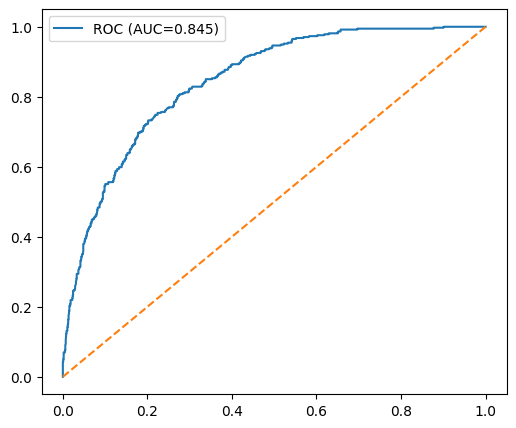


PR-AUC: 0.662
   Precision  Recall
0   0.265436     1.0
1   0.266003     1.0
2   0.266382     1.0
3   0.266762     1.0
4   0.266952     1.0


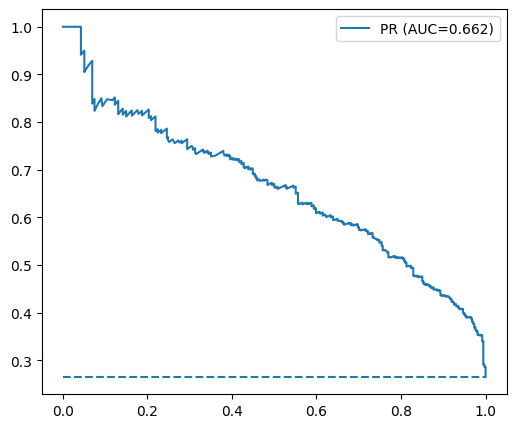

In [11]:
y_prob = y_prob_gb_tuned

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(roc_auc, 4))
print("ROC curve sample points (first 5):")
print(pd.DataFrame({"FPR": fpr[:5], "TPR": tpr[:5], "Threshold": roc_thresholds[:5]}))

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],"--")
plt.legend()
plt.show()

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
baseline = y_test.mean()

print("\nPR-AUC:", round(pr_auc, 4))
print(pd.DataFrame({"Precision": precision[:5], "Recall": recall[:5]}))

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR (AUC={pr_auc:.3f})")
plt.hlines(y=baseline, xmin=0, xmax=1, linestyles="--")
plt.legend()
plt.show()

- The tuned Gradient Boosting model achieves ROC-AUC = **0.8454** and PR-AUC = **0.662**, substantially exceeding the baseline churn rate (0.265), confirming strong class separability and positive-class ranking.
- The ROC curve shows rapid TPR gains at low FPR, while the Precision–Recall curve maintains precision well above baseline across most recall levels, indicating stable ranking performance and practical utility for identifying high-risk churn customers.

## Threshold Optimization & Confusion Matrix


Threshold Sweep Summary (first rows)
----------------------------------
   Threshold  Recall  Precision        F1    FP  FN
0     0.0114     1.0   0.265436  0.419518  1035   0
1     0.0119     1.0   0.266003  0.420225  1032   0
2     0.0123     1.0   0.266382  0.420697  1030   0
3     0.0124     1.0   0.266762  0.421171  1028   0
4     0.0128     1.0   0.267143  0.421646  1026   0

Recall Range: 0.0 → 1.0
Precision Range: 0.0 → 1.0

Selected Threshold (Recall + Precision constrained, Max F1)
---------------------------------------------------------
Threshold      0.339400
Recall         0.732620
Precision      0.567288
F1             0.639440
FP           209.000000
FN           100.000000
Name: 771, dtype: float64

Confusion Matrix Values (Threshold = 0.3394)
----------------------------------------
TN: 826, FP: 209, FN: 100, TP: 274

Final Metrics at Threshold = 0.3394
--------------------------------
Recall: 0.7326
Precision: 0.5673
F1: 0.6394
MCC: 0.4937


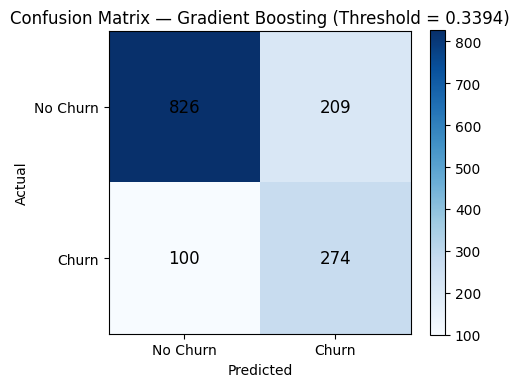

Churners captured: 274 / 374
Customers flagged: 483


In [12]:
thresholds = np.unique(np.round(y_prob, 5))
rows = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    rows.append({
        "Threshold": round(t, 4),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "FP": fp,
        "FN": fn,
    })

threshold_df = pd.DataFrame(rows)

print("\nThreshold Sweep Summary (first rows)")
print("----------------------------------")
print(threshold_df.head())

print("\nRecall Range:", threshold_df["Recall"].min(), "→", threshold_df["Recall"].max())
print("Precision Range:", threshold_df["Precision"].min(), "→", threshold_df["Precision"].max())

MIN_RECALL = 0.70
MIN_PRECISION = 0.35

eligible = threshold_df[
    (threshold_df["Recall"] >= MIN_RECALL) &
    (threshold_df["Precision"] >= MIN_PRECISION)
]

if len(eligible) == 0:
    print("\nPrecision constraint too strict. Relaxing...")
    eligible = threshold_df[threshold_df["Recall"] >= MIN_RECALL]

if len(eligible) == 0:
    print("\nRecall constraint too strict. Using global F1.")
    eligible = threshold_df.copy()

best_row = eligible.sort_values("F1", ascending=False).iloc[0]
final_threshold = best_row["Threshold"]

print("\nSelected Threshold (Recall + Precision constrained, Max F1)")
print("---------------------------------------------------------")
print(best_row)

y_final_pred = (y_prob >= final_threshold).astype(int)

cm = confusion_matrix(y_test, y_final_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix Values (Threshold = {final_threshold})")
print("----------------------------------------")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

final_metrics = {
    "Recall": recall_score(y_test, y_final_pred),
    "Precision": precision_score(y_test, y_final_pred, zero_division=0),
    "F1": f1_score(y_test, y_final_pred, zero_division=0),
    "MCC": matthews_corrcoef(y_test, y_final_pred),
}

print(f"\nFinal Metrics at Threshold = {final_threshold}")
print("--------------------------------")
for k,v in final_metrics.items():
    print(f"{k}: {v:.4f}")

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title(f"Confusion Matrix — Gradient Boosting (Threshold = {final_threshold})")
plt.colorbar()

labels = ["No Churn", "Churn"]
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Churners captured:", tp, "/", tp+fn)
print("Customers flagged:", tp+fp)

- Constraint-based threshold selection (Recall ≥ 0.70, Precision ≥ 0.35) produced an optimal threshold of **0.3394**, yielding Recall **0.7326**, Precision **0.5673**, F1 **0.6394**, and MCC **0.4937**.
- At this operating point, the model correctly identifies **274 of 374 churners (73.3%)** while flagging **483 customers** in total, providing a balanced trade-off between churn capture and intervention volume.

## Feature Importance & Model Serialization

In [13]:
preprocessor = best_gb_model.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

importances = best_gb_model.named_steps["classifier"].feature_importances_

feature_importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 Feature Importances")
print("--------------------------")
print(feature_importance_df.head(15))

joblib.dump(best_gb_model, "../artifacts/churn_model.joblib")
print("\nModel saved as 'churn_model.joblib'")

Top 15 Feature Importances
--------------------------
                                Feature  Importance
0          cat__Contract_Month-to-month    0.358058
1                           num__tenure    0.182940
2      cat__InternetService_Fiber optic    0.131319
3                cat__OnlineSecurity_No    0.082976
4   cat__PaymentMethod_Electronic check    0.049716
5                   num__MonthlyCharges    0.047112
6                   cat__TechSupport_No    0.047064
7                     num__TotalCharges    0.039071
8                 cat__MultipleLines_No    0.009915
9             cat__PaperlessBilling_Yes    0.009716
10               cat__Contract_Two year    0.009352
11                 cat__OnlineBackup_No    0.008679
12             cat__PaperlessBilling_No    0.007378
13                 cat__StreamingTV_Yes    0.003881
14             cat__StreamingMovies_Yes    0.003732

Model saved as 'churn_model.joblib'
